<a href="https://colab.research.google.com/github/4ts7n/Traffic-Sign-Recognition-System-Using-TensorFlow/blob/main/Traffic_Sign_Recognition_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Upload kaggle.json first
!pip install kaggle
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
!unzip -q gtsrb-german-traffic-sign.zip -d gtsrb

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
License(s): CC0-1.0
100% 612M/612M [00:05<00:00, 110MB/s]



In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, applications
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pathlib
import os
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import PIL
import cv2

print("TensorFlow version:", tf.__version__)



TensorFlow version: 2.20.0


In [6]:
# Part I : Data Loading
data_dir = pathlib.Path("gtsrb/Train")
test_dir = pathlib.Path("gtsrb/Test")

img_height = 64
img_width = 64
batch_size = 32
num_classes = 43

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

class_names = train_ds.class_names
print("Number of classes:", len(class_names))



Found 39209 files belonging to 43 classes.
Using 31368 files for training.
Found 39209 files belonging to 43 classes.
Using 7841 files for validation.
Number of classes: 43


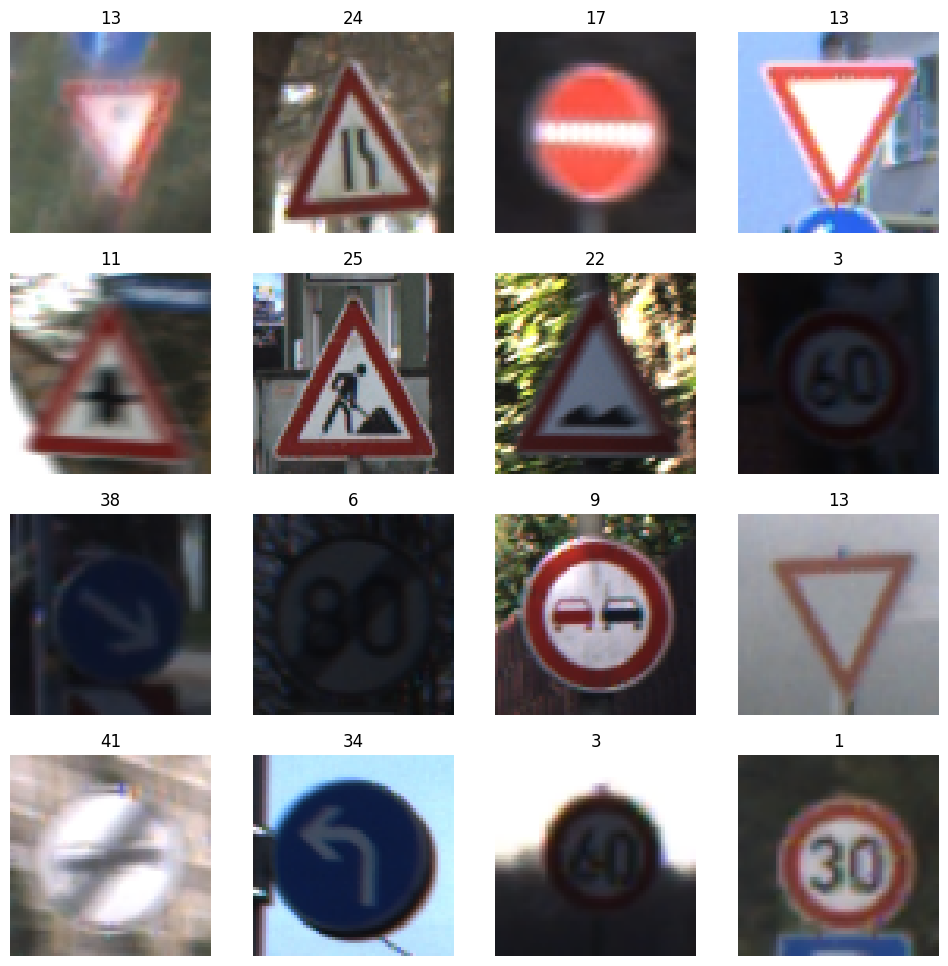

In [7]:
# part II: data preproessing
# Visualize samples
plt.figure(figsize=(12, 12))
for images, labels in train_ds.take(1):
    for i in range(16):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

# Optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

In [8]:
# part III: CNN model
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,201,707 (8.40 MB)

 Trainable params: 2,201,707 (8.40 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Part IV: modl training and evaluation
history = model.fit(train_ds, validation_data=val_ds, epochs=15)

Epoch 1/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 382s 358ms/step - accuracy: 0.7676 - loss: 0.8210 - val_accuracy: 0.9633 - val_loss: 0.1321
Epoch 2/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 343s 346ms/step - accuracy: 0.9792 - loss: 0.0740 - val_accuracy: 0.9823 - val_loss: 0.0666
Epoch 3/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 374s 338ms/step - accuracy: 0.9895 - loss: 0.0370 - val_accuracy: 0.9875 - val_loss: 0.0636
Epoch 4/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 335s 341ms/step - accuracy: 0.9920 - loss: 0.0277 - val_accuracy: 0.9834 - val_loss: 0.0834
Epoch 5/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 335s 342ms/step - accuracy: 0.9941 - loss: 0.0216 - val_accuracy: 0.9867 - val_loss: 0.0638
Epoch 6/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 379s 339ms/step - accuracy: 0.9942 - loss: 0.0193 - val_accuracy: 0.9941 - val_loss: 0.0405
Epoch 7/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 382s 339ms/step - accuracy: 0.9965 - loss: 0.0144 - val_accuracy: 0.9879 - val_loss: 0.0544
Epoch 8/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 342s 349ms/step - accuracy: 0.9944 -

NameError: name 'epochs' is not defined

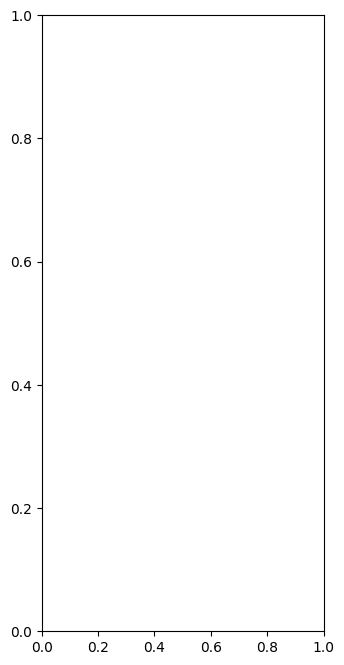

In [35]:
#  Plot training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(epochs), acc, label='Training Accuracy')
plt.plot(range(epochs), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(epochs), loss, label='Training Loss')
plt.plot(range(epochs), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [12]:
# Detailed Evaluation
val_images = []
val_labels = []
for images, labels in val_ds:
    val_images.append(images)
    val_labels.append(labels)
val_images = np.concatenate(val_images)
val_labels = np.concatenate(val_labels)

predictions = model.predict(val_images)
pred_classes = np.argmax(predictions, axis=1)

print(classification_report(val_labels, pred_classes, target_names=class_names))

246/246 ━━━━━━━━━━━━━━━━━━━━ 22s 88ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        48
           1       1.00      0.99      0.99       468
          10       1.00      1.00      1.00       418
          11       0.99      1.00      0.99       275
          12       1.00      1.00      1.00       425
          13       1.00      1.00      1.00       449
          14       1.00      0.99      1.00       156
          15       1.00      1.00      1.00       127
          16       1.00      1.00      1.00        78
          17       0.99      1.00      1.00       225
          18       1.00      0.99      1.00       234
          19       1.00      0.96      0.98        54
           2       1.00      1.00      1.00       442
          20       0.98      1.00      0.99        84
          21       0.98      1.00      0.99        63
          22       1.00      1.00      1.00        90
          23       1.00      0.96     

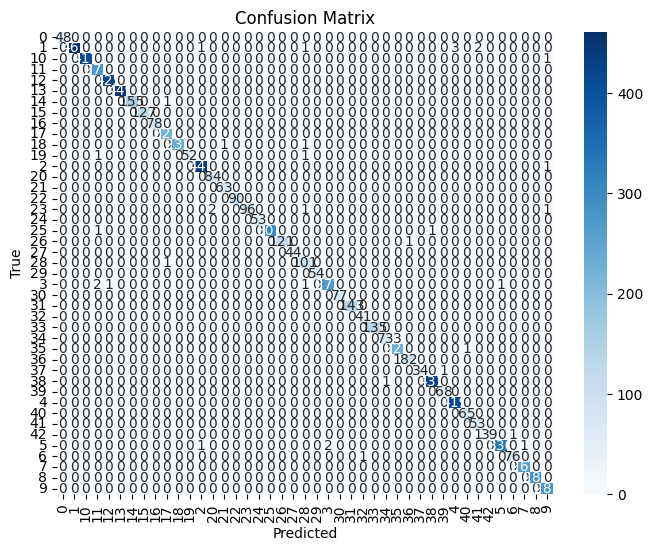

In [13]:
# Confusion Matrix
cm = confusion_matrix(val_labels, pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [14]:
# Part V: model optimization
# Strong data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.2),
])

# Transfer Learning
base_model = applications.EfficientNetB0(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model_opt = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes)
])

model_opt.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])

# Callbacks
callbacks_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
    callbacks.ModelCheckpoint('best_traffic_sign_model.keras', save_best_only=True, monitor='val_accuracy')
]

history_opt = model_opt.fit(train_ds, validation_data=val_ds, epochs=30, callbacks=callbacks_list)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 298s 285ms/step - accuracy: 0.0563 - loss: 3.6633 - val_accuracy: 0.0573 - val_loss: 3.6106 - learning_rate: 0.0010
Epoch 2/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 320s 326ms/step - accuracy: 0.0634 - loss: 3.5110 - val_accuracy: 0.0704 - val_loss: 3.5270 - learning_rate: 0.0010
Epoch 3/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 278s 281ms/step - accuracy: 0.0662 - loss: 3.4811 - val_accuracy: 0.0869 - val_loss: 3.4661 - learning_rate: 0.0010
Epoch 4/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 269s 274ms/step - accuracy: 0.0678 - loss: 3.4729 - val_accuracy: 0.0805 - val_loss: 3.4499 - learning_rate: 0.0010
Epoch 5/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 271s 276ms/step - accuracy: 0.0700 - loss: 3.4701 - val_accuracy: 0.0796 - val_loss: 3.4592 - learning_rate: 0.0010
Epoch 6/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 270s 275ms/step - accuracy: 0.0701 - loss: 3.4609 - val_accuracy: 0.0884 - val_loss: 3.4578 - learning_rate: 0.0010
Epoch 7/30
98

In [22]:
from google.colab import files

uploaded = files.upload()


Saving roadwork.png to roadwork.png


In [32]:
# Part VI:Upload  new traffic sign images
def predict_sign(image_path, model):
    img = tf.keras.utils.load_img(image_path, target_size=(img_height, img_width))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])

    print(f"Predicted: {class_names[np.argmax(score)]} ({100 * np.max(score):.2f}%)")

# Call the function
predict_sign("roadwork.png", model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Predicted: 23 (97.01%)


In [36]:
# Save
model_opt.save('traffic_sign_model.keras')
model_opt.save('traffic_sign_model.h5')

# TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model_opt)
tflite_model = converter.convert()
with open('traffic_sign_model.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmp6h9x3bma'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='keras_tensor_249')
Output Type:
  TensorSpec(shape=(None, 43), dtype=tf.float32, name=None)
Captures:
  138520262437072: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138520262438608: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138520799902992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138520799900112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138520799900304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138520799901264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138520799902800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138520799902608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138520799901648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138523168741072: TensorSpec(shape=(), dtype=tf.resource, name=N